# Tarea Breast Cancer Wisconsin (Diagnostic) Data Set
# Lucy Torres Durante



## 1. Analisis exploratorio

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


sns.set(style="whitegrid")

# Cargar datos, convirtiendo "?" en NaN
df = pd.read_csv("breast-cancer-wisconsin.csv", na_values="?")

# Limpiar nombres de columnas
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df = df.rename(columns={
    "Sample_code_number": "id",
    "Class": "class"
})


display(df.head())
display(df.tail())

,id,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


,id,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,class
694,776715,3,1,1,1,3,2.0,1,1,1,2
695,841769,2,1,1,1,2,1.0,1,1,1,2
696,888820,5,10,10,3,7,3.0,8,10,2,4
697,897471,4,8,6,4,3,4.0,10,6,1,4
698,897471,4,8,8,5,4,5.0,10,4,1,4


In [99]:
display("Dimensiones:", df.shape)
display(df.info())
display(df.describe(include="all"))
display("\nValores nulos por columna:")
display(df.isna().sum())

'Dimensiones:'

(699, 11)

<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           699 non-null    int64  
 1   Clump_Thickness              699 non-null    int64  
 2   Uniformity_of_Cell_Size      699 non-null    int64  
 3   Uniformity_of_Cell_Shape     699 non-null    int64  
 4   Marginal_Adhesion            699 non-null    int64  
 5   Single_Epithelial_Cell_Size  699 non-null    int64  
 6   Bare_Nuclei                  683 non-null    float64
 7   Bland_Chromatin              699 non-null    int64  
 8   Normal_Nucleoli              699 non-null    int64  
 9   Mitoses                      699 non-null    int64  
 10  class                        699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


None

,id,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


'\nValores nulos por columna:'

id                              0
Clump_Thickness                 0
Uniformity_of_Cell_Size         0
Uniformity_of_Cell_Shape        0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
class                           0
dtype: int64

Ya se pasaron a enteros o flotantes. 

## 2. Limpieza de datos.

Vamos a quitar nulos, duplicados, cambiar las etiquetas de clase por algo mas legible para las personas.

In [100]:
# ANTES
print(df.columns.tolist())
tabla_antes = df.isna().sum().to_frame("Nulos")

display("=== ANTES ===")
display(tabla_antes)
display(f"Filas duplicadas (totales): {df.duplicated().sum()}")

# Filas que están duplicadas con el mismo id. (son la misma persona)
print("ids repetidos:", df["id"].duplicated().sum())

['id', 'Clump_Thickness', 'Uniformity_of_Cell_Size', 'Uniformity_of_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'class']


'=== ANTES ==='

,Nulos
id,0
Clump_Thickness,0
Uniformity_of_Cell_Size,0
Uniformity_of_Cell_Shape,0
Marginal_Adhesion,0
Single_Epithelial_Cell_Size,0
Bare_Nuclei,16
Bland_Chromatin,0
Normal_Nucleoli,0
Mitoses,0


'Filas duplicadas (totales): 8'

ids repetidos: 54


In [101]:
# Eliminar nulos.
df["Bare_Nuclei"] = df["Bare_Nuclei"].fillna(df["Bare_Nuclei"].median())

# Eliminar duplicados por id (mismo id = mismo paciente).
print("Ids repetidos:", df["id"].duplicated().sum())
df = df.drop_duplicates(subset=["id"], keep="first")

# Cambiar etiquetas de clase a benigno/maligno para mejor entendimiento.
df["class_label"] = df["class"].map({2: "Benigno", 4: "Maligno"})
df["class_bin"] = df["class"].map({2: 0, 4: 1})


Ids repetidos: 54


In [102]:
# Despues
tabla_despues = df.isna().sum().to_frame("Nulos")

display("=== DESPUES ===")
display(tabla_despues)
display(f"Filas duplicadas (totales): {df.duplicated().sum()}")
# Filas que están duplicadas con el mismo id. (son la misma persona)
print("ids repetidos:", df["id"].duplicated().sum())

'=== DESPUES ==='

,Nulos
id,0
Clump_Thickness,0
Uniformity_of_Cell_Size,0
Uniformity_of_Cell_Shape,0
Marginal_Adhesion,0
Single_Epithelial_Cell_Size,0
Bare_Nuclei,0
Bland_Chromatin,0
Normal_Nucleoli,0
Mitoses,0


'Filas duplicadas (totales): 0'

ids repetidos: 0


Vamos a quitar el id, introduce ruido a la hora de hacer histogramas/boxplots.

In [103]:
# Después de deduplicar
df = df.drop(columns=["id"])

## 2.1 Analisis univariado

In [104]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Clump_Thickness,645.0,4.471318,2.858115,1.0,2.0,4.0,6.0,10.0
Uniformity_of_Cell_Size,645.0,3.182946,3.059049,1.0,1.0,1.0,5.0,10.0
Uniformity_of_Cell_Shape,645.0,3.269767,2.985748,1.0,1.0,2.0,5.0,10.0
Marginal_Adhesion,645.0,2.893023,2.918036,1.0,1.0,1.0,4.0,10.0
Single_Epithelial_Cell_Size,645.0,3.275969,2.247455,1.0,2.0,2.0,4.0,10.0
Bare_Nuclei,645.0,3.559690,3.647715,1.0,1.0,1.0,6.0,10.0
Bland_Chromatin,645.0,3.497674,2.459374,1.0,2.0,3.0,5.0,10.0
Normal_Nucleoli,645.0,2.955039,3.120682,1.0,1.0,1.0,4.0,10.0
Mitoses,645.0,1.613953,1.744056,1.0,1.0,1.0,1.0,10.0
class,645.0,2.719380,0.960564,2.0,2.0,2.0,4.0,4.0


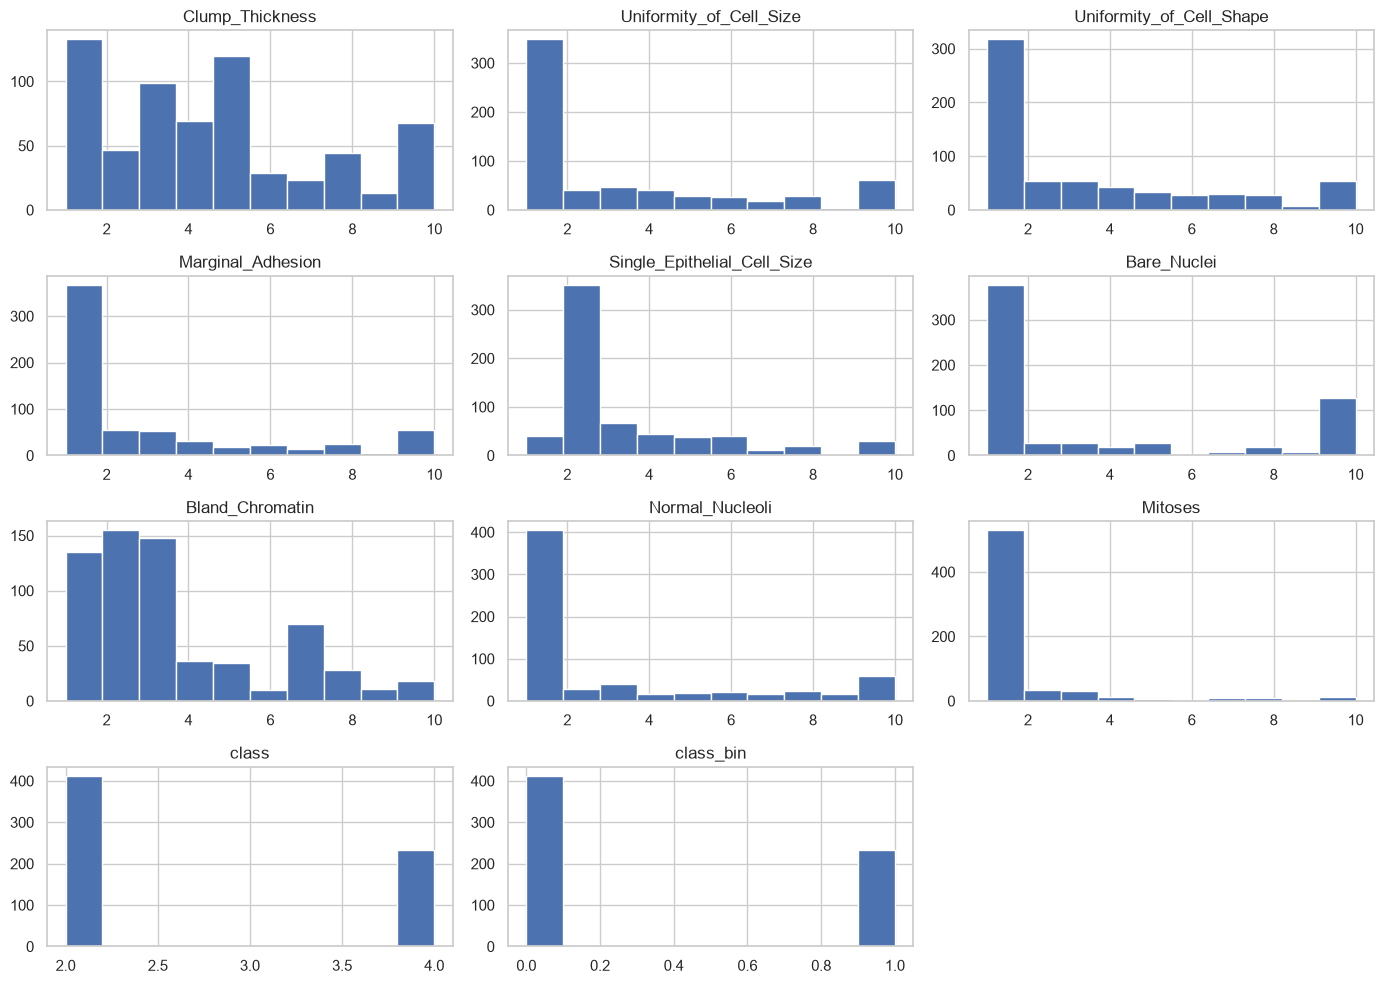

In [105]:
df.hist(figsize=(14, 10), bins=10)
plt.tight_layout()
plt.show()

### `Clump_Thickness`
**Qué significa:** Grosor del grupo de células. Es la variable más "repartida" de todas. Tiene picos en 1 (muy delgadas) y también en 4, 5, 8 y 10. Lo que dice que hay un poco de todo, desde casos muy normales hasta casos con células muy agrupadas y gruesas.

### `Uniformity_of_Cell_Size`
**Qué significa:** Qué tan uniforme es el tamaño de las células. Súper sesgada a la izquierda (pico enorme en 1 y 2): la mayoría de las muestras tienen células de tamaño uniforme. La cola hacia 10 representa los casos donde las células varían mucho de tamaño, típico de malignidad.

### `Uniformity_of_Cell_Shape`
**Qué significa:** Qué tan uniforme es la forma de las células. Idéntico patrón a la anterior: pico en 1, cola larga hasta 10. La mayoría son uniformes; los valores altos indican formas irregulares, otra señal de cáncer.

### `Marginal_Adhesion`
**Qué significa:** Qué tan pegadas están las células entre sí. Pico muy fuerte en 1: la mayoría de las células se adhieren normalmente. Los valores altos (5-10) indican pérdida de adhesión, algo característico de células cancerosas que se desprenden.

### `Single_Epithelial_Cell_Size`
**Qué significa:** Tamaño de las células epiteliales individuales. Aquí el pico está en 2 (no en 1), lo cual es normal en este tipo de célula. La cola hacia 10 muestra casos donde las células crecieron anormalmente.

### `Bare_Nuclei`
**Qué significa:** Núcleos "desnudos" (sin citoplasma alrededor). Pico enorme en 1 (casi no hay núcleos desnudos) y un segundo pico en 10. Esa segunda barra alta en 10 es muy relevante: muchas muestras tienen núcleos desnudos abundantes, lo cual es una señal fuerte de malignidad.

### `Bland_Chromatin`
**Qué significa:** Textura del material genético (cromatina). Es una de las más "repartidas": tiene masa entre 2 y 5, y una cola importante hasta 10. Esto significa que la textura varía mucho entre muestras. Los valores altos (cromatina gruesa) se asocian a cáncer.

### `Normal_Nucleoli`
**Qué significa:** Presencia de nucléolos normales. Pico gigante en 1 (nucléolos normales, casi invisibles) y cola hasta 10. Los valores altos significan nucléolos muy visibles y agrandados, señal de actividad celular anormal.

### `Mitoses`
**Qué significa:** Número de divisiones celulares. Prácticamente todo está en 1 (casi no hay mitosis). Hay una barrita mínima en 10. Esta variable tiene muy poca varianza: casi todas las muestras valen lo mismo. 

### `class`
**Qué significa:** La variable objetivo original. Barra en 2 (Benigno) de ~450 y barra en 4 (Maligno) de ~240. Esto te dice que el dataset está desbalanceado: aproximadamente 65% benignos y 35% malignos.

### `class_bin`
**Qué significa:** Lo mismo que `class` pero en formato 0/1 (0 = Benigno, 1 = Maligno). 

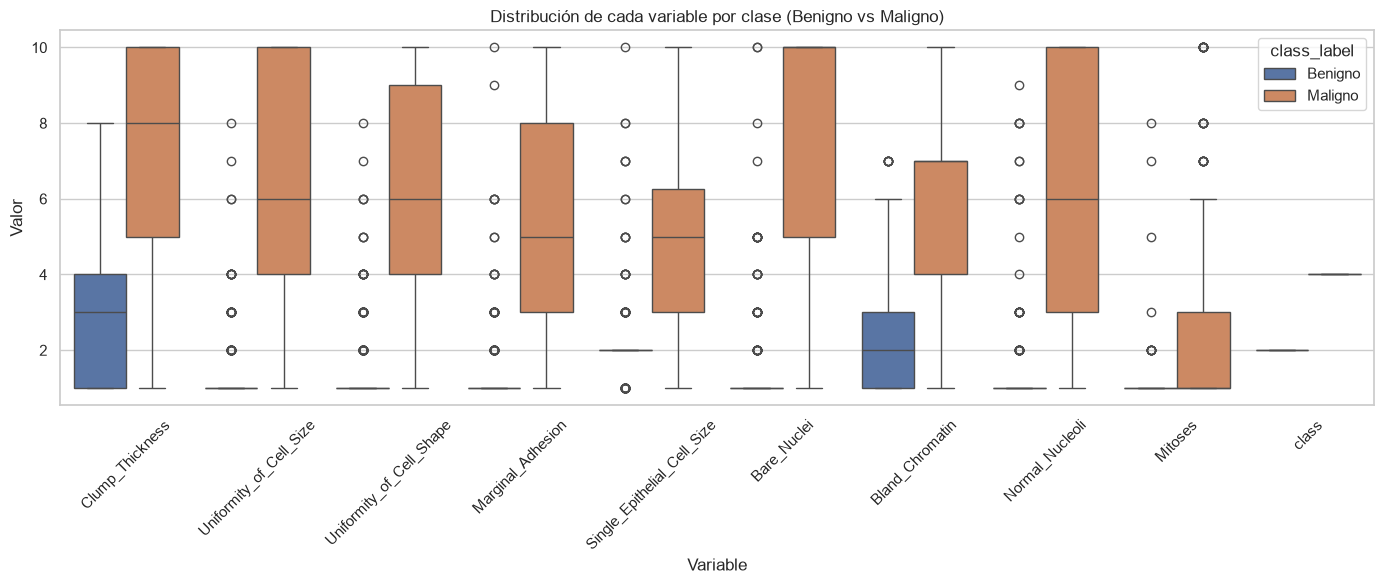

In [106]:

# Pasar el DataFrame a formato "largo" para poder separar por clase
df_melt = df.drop(columns=[ "class_bin"]).melt(
    id_vars="class_label",
    var_name="Variable",
    value_name="Valor"
)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_melt, x="Variable", y="Valor", hue="class_label")
plt.xticks(rotation=45)
plt.title("Distribución de cada variable por clase (Benigno vs Maligno)")
plt.tight_layout()
plt.show()

En este boxplot se observa un desbalance de clases (más benignos que malignos). Las variables que mejor separan a los pacientes son Bare_Nuclei y Normal_Nucleoli, seguidas de Uniformity_of_Cell_Size y Clump_Thickness. Esto se debe a que sus cajas están a alturas muy distintas entre clases, no porque sean grandes. La variable Mitoses tiene muy poca varianza en benignos, pero en malignos muestra valores altos aislados, lo que sugiere un subgrupo de tumores muy agresivos. Sin embargo, existe solapamiento en casi todas las variables, por lo que ninguna es predictiva por sí sola.

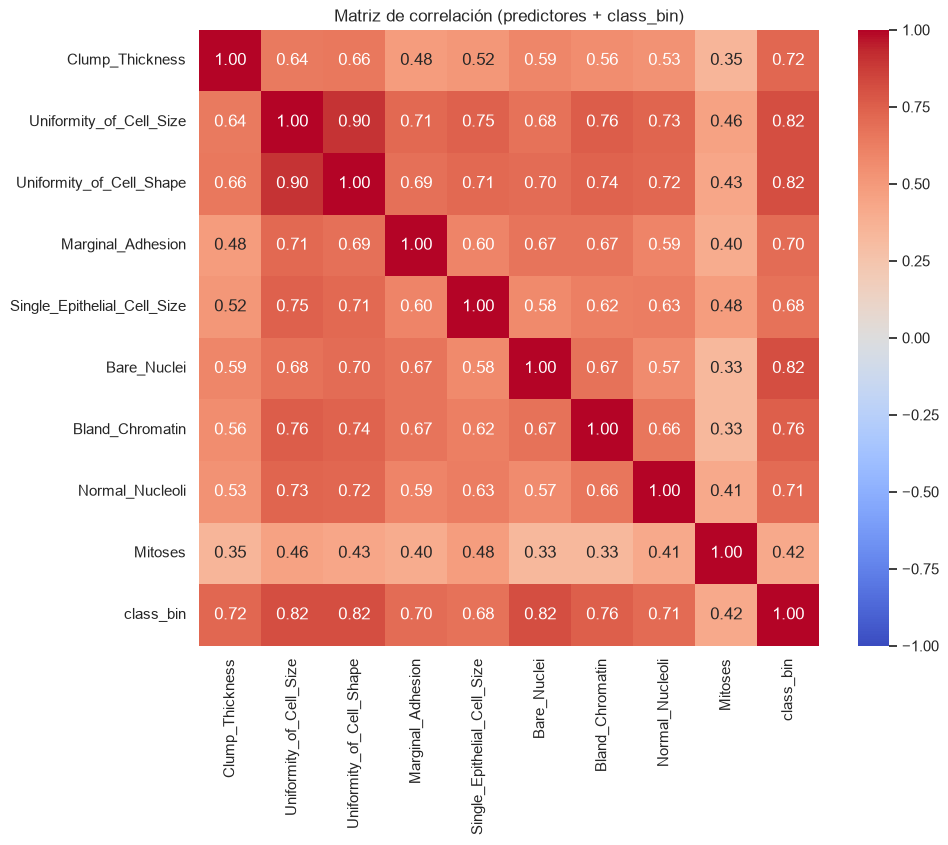

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

# Excluir class y class_label (dejar solo class_bin como objetivo)
cols = [c for c in df.columns if c not in [ "class", "class_label"]]

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de correlación (predictores + class_bin)")
plt.show()

Las variables más predictivas de malignidad son Uniformity_of_Cell_Size, Uniformity_of_Cell_Shape y Bare_Nuclei (r = 0.82 con la clase). Se detectó multicolinealidad alta entre las dos primeras (r = 0.90), por lo que para modelos lineales conviene considerar eliminar una. Mitoses es la variable con menor poder predictivo (r = 0.42).

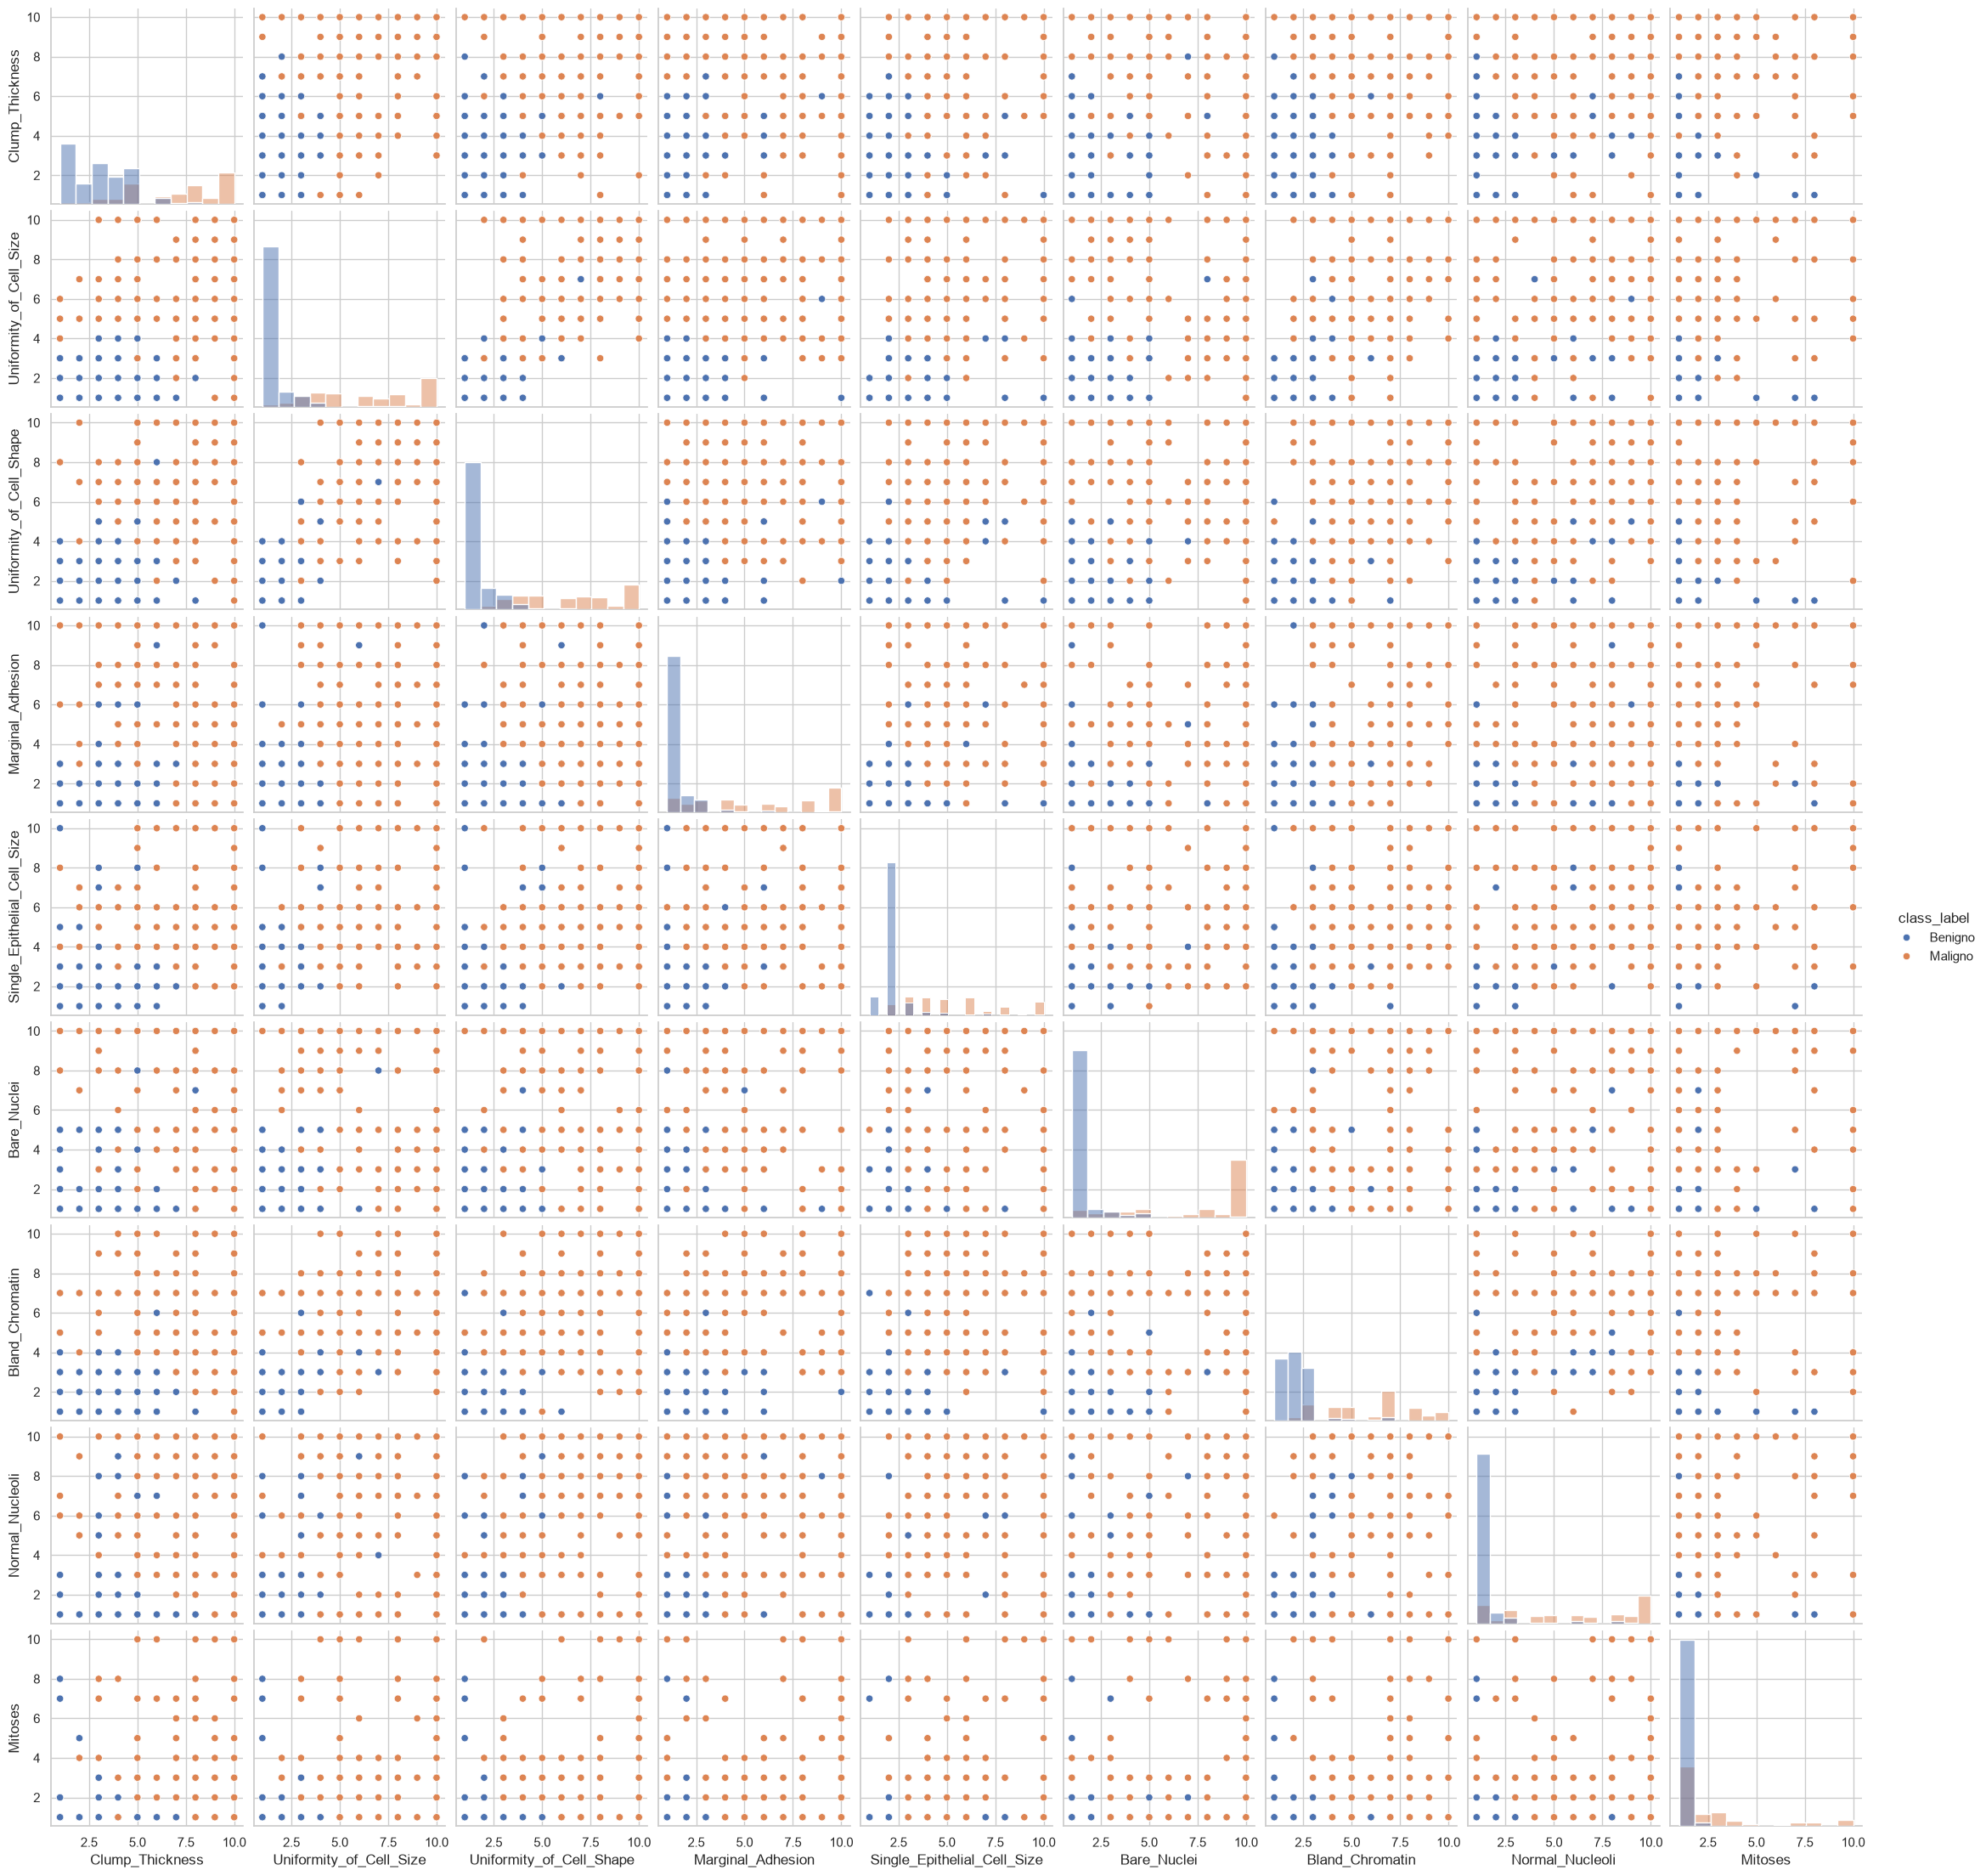

In [115]:
sns.pairplot(
    df.drop(columns=["class", "class_bin"]),
    hue="class_label",
    diag_kind="hist"
)
plt.show()

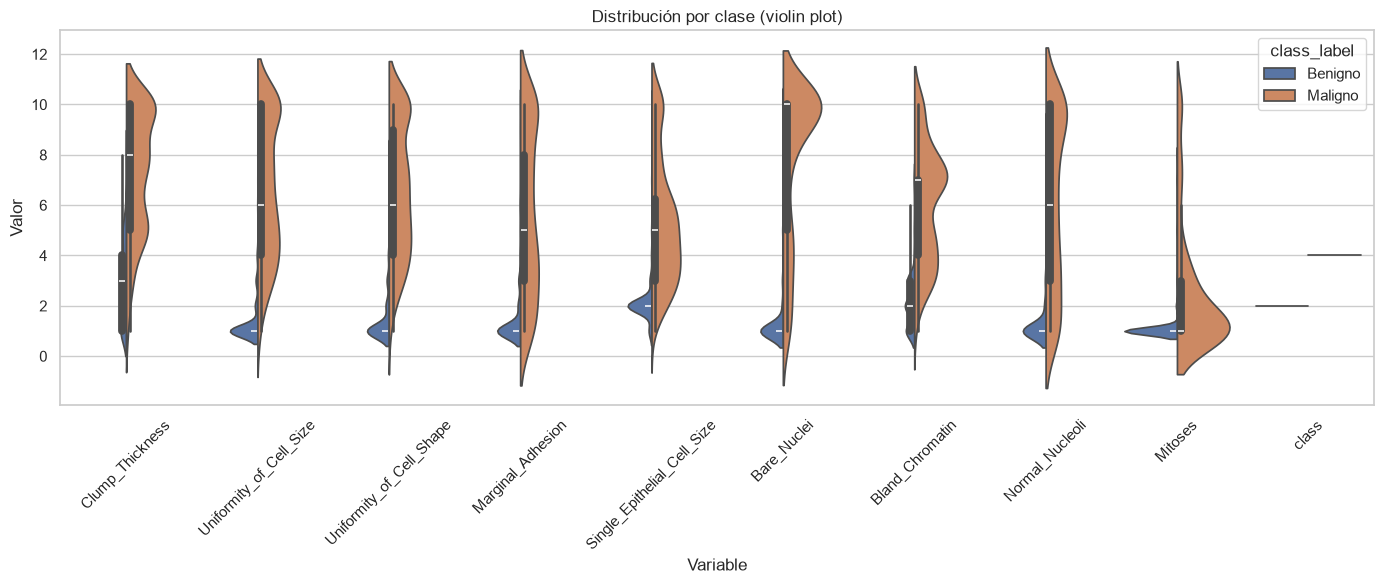

In [109]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=df_melt, x="Variable", y="Valor", hue="class_label", split=True)
plt.xticks(rotation=45)
plt.title("Distribución por clase (violin plot)")
plt.tight_layout()
plt.show()

Hice las graficas de pairplot y de violin, pero creo que la que aporta mas informacion es el heatmap.

In [116]:
df.drop(columns=["class"]).groupby("class_label").mean(numeric_only=True)

,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,class_bin
class_label,,,,,,,,,,
Benigno,2.920097,1.309927,1.445521,1.363196,2.133172,1.326877,2.106538,1.295400,1.065375,0.0
Maligno,7.232759,6.517241,6.517241,5.616379,5.310345,7.534483,5.974138,5.909483,2.590517,1.0


In [111]:
num_cols = df.select_dtypes(include=np.number).columns.drop(["class", "class_bin"], errors="ignore")

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[num_cols] < Q1 - 1.5 * IQR) |
            (df[num_cols] > Q3 + 1.5 * IQR)).sum()

print(outliers)

Clump_Thickness                  0
Uniformity_of_Cell_Size          0
Uniformity_of_Cell_Shape         0
Marginal_Adhesion               59
Single_Epithelial_Cell_Size     52
Bare_Nuclei                      0
Bland_Chromatin                 18
Normal_Nucleoli                 76
Mitoses                        115
dtype: int64


## 3. Reduccion de dimensionalidad con PCA y extraccion de caracteristicas

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Separar predictores y clase
X = df.drop(columns=["class","class_label", "class_bin"])
y = df["class_bin"]


display(X)
display(y)
# 2. Dividir train/test ANTES de cualquier transformación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Estandarizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # solo transform, NO fit

# 4. PCA (guardamos el 95% de la varianza)
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)  # solo transform, NO fit

print(f"Componentes retenidos: {pca.n_components_}")
print(f"Varianza explicada: {pca.explained_variance_ratio_.sum():.2%}")

# 5. SVM
svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train_pca, y_train)
y_pred_svm = svm.predict(X_test_pca)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

# 6. Red neuronal simple (MLP)
mlp = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42)
mlp.fit(X_train_pca, y_train)
y_pred_mlp = mlp.predict(X_test_pca)
print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))

,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1
...,...,...,...,...,...,...,...,...,...
693,3,1,1,1,2,1.0,2,1,2
694,3,1,1,1,3,2.0,1,1,1
695,2,1,1,1,2,1.0,1,1,1
696,5,10,10,3,7,3.0,8,10,2


0      0
1      0
2      0
3      0
4      0
      ..
693    0
694    0
695    0
696    1
697    1
Name: class_bin, Length: 645, dtype: int64

Componentes retenidos: 7
Varianza explicada: 96.17%
SVM Accuracy: 0.9534883720930233
MLP Accuracy: 0.9457364341085271


In [118]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Separar predictores y clase
X = df.drop(columns=["class", "class_label", "class_bin"])
y = df["class_bin"]

display(X)
display(y)

# 2. Dividir train/test ANTES de cualquier transformación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Estandarizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4. SVM (sin PCA)
svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print("SVM sin PCA — Accuracy:", accuracy_score(y_test, y_pred_svm))

# 5. Red neuronal simple (MLP, sin PCA)
mlp = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)
print("MLP sin PCA — Accuracy:", accuracy_score(y_test, y_pred_mlp))

,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1
...,...,...,...,...,...,...,...,...,...
693,3,1,1,1,2,1.0,2,1,2
694,3,1,1,1,3,2.0,1,1,1
695,2,1,1,1,2,1.0,1,1,1
696,5,10,10,3,7,3.0,8,10,2


0      0
1      0
2      0
3      0
4      0
      ..
693    0
694    0
695    0
696    1
697    1
Name: class_bin, Length: 645, dtype: int64

SVM sin PCA — Accuracy: 0.9534883720930233
MLP sin PCA — Accuracy: 0.9534883720930233


In [120]:
from sklearn.model_selection import cross_val_score

# SVM sin PCA
svm = SVC(kernel="rbf", random_state=42)
scores = cross_val_score(svm, X_train_scaled, y_train, cv=5, scoring="accuracy")
print("SVM sin PCA — CV accuracy:", scores.mean(), "±", scores.std())

# MLP sin PCA
mlp = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42)
scores = cross_val_score(mlp, X_train_scaled, y_train, cv=5, scoring="accuracy")
print("MLP sin PCA — CV accuracy:", scores.mean(), "±", scores.std())

SVM sin PCA — CV accuracy: 0.9689320388349515 ± 0.018825941193849813
MLP sin PCA — CV accuracy: 0.9805825242718447 ± 0.01736751827184302


In [121]:
from sklearn.metrics import classification_report, confusion_matrix

print("=== SVM sin PCA ===")
print(classification_report(y_test, y_pred_svm, target_names=["Benigno", "Maligno"]))
print(confusion_matrix(y_test, y_pred_svm))

print("\n=== MLP sin PCA ===")
print(classification_report(y_test, y_pred_mlp, target_names=["Benigno", "Maligno"]))
print(confusion_matrix(y_test, y_pred_mlp))

=== SVM sin PCA ===
              precision    recall  f1-score   support

     Benigno       0.99      0.94      0.96        83
     Maligno       0.90      0.98      0.94        46

    accuracy                           0.95       129
   macro avg       0.94      0.96      0.95       129
weighted avg       0.96      0.95      0.95       129

[[78  5]
 [ 1 45]]

=== MLP sin PCA ===
              precision    recall  f1-score   support

     Benigno       0.98      0.95      0.96        83
     Maligno       0.92      0.96      0.94        46

    accuracy                           0.95       129
   macro avg       0.95      0.95      0.95       129
weighted avg       0.95      0.95      0.95       129

[[79  4]
 [ 2 44]]


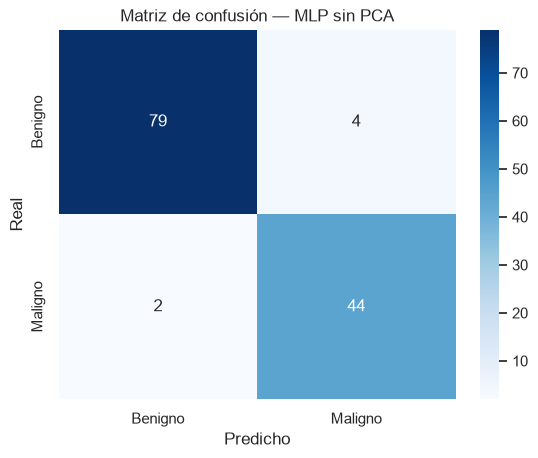

              precision    recall  f1-score   support

     Benigno       0.98      0.95      0.96        83
     Maligno       0.92      0.96      0.94        46

    accuracy                           0.95       129
   macro avg       0.95      0.95      0.95       129
weighted avg       0.95      0.95      0.95       129



In [122]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Reentrenar MLP sin PCA en el split original
mlp = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benigno", "Maligno"],
            yticklabels=["Benigno", "Maligno"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión — MLP sin PCA")
plt.show()

print(classification_report(y_test, y_pred, target_names=["Benigno", "Maligno"]))

Mediante validación cruzada de 5 folds, el MLP sin PCA obtuvo el mejor rendimiento (98.1% ± 1.7%), superando al SVM sin PCA (96.9% ± 1.9%). 

PCA no mostró mejoras en el split único, y se descartó por sacrificar interpretabilidad sin ganancia en accuracy.